# Partition RART — Clean Resolution Scaling Notebook

This version is self-contained and designed for reproducible Kaggle execution. It removes the fragile notebook-import/state dependency and the experimental Swin monkey-patching cells.

In [1]:
import gc
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")


Device: cuda
GPU: Tesla T4
VRAM: 14.56 GB


In [2]:
class PatchEmbedding(nn.Module):

    def __init__(self, image_size=224, patch_size=16, in_channels=3, embed_dim=384):
        super().__init__()
        assert image_size % patch_size == 0
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.projection = nn.Conv2d(in_channels=in_channels, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.projection(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

class ViTInputEmbedding(nn.Module):

    def __init__(self, num_patches, embed_dim=384):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim) * 0.02)

    def forward(self, x):
        batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embedding
        return x

class MultiHeadSelfAttention(nn.Module):

    def __init__(self, embed_dim=384, num_heads=6, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** (-0.5)
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.projection = nn.Linear(embed_dim, embed_dim)
        self.attention_dropout = nn.Dropout(dropout)
        self.projection_dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, num_tokens, embed_dim = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(batch_size, num_tokens, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attention_scores = q @ k.transpose(-2, -1) * self.scale
        attention_weights = attention_scores.softmax(dim=-1)
        attention_weights = self.attention_dropout(attention_weights)
        x = attention_weights @ v
        x = x.transpose(1, 2).reshape(batch_size, num_tokens, embed_dim)
        x = self.projection(x)
        x = self.projection_dropout(x)
        return x

class FeedForward(nn.Module):

    def __init__(self, embed_dim=384, hidden_dim=1536, dropout=0.0):
        super().__init__()
        self.network = nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, embed_dim), nn.Dropout(dropout))

    def forward(self, x):
        return self.network(x)

class TransformerBlock(nn.Module):

    def __init__(self, embed_dim=384, num_heads=6, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = MultiHeadSelfAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.ffn = FeedForward(embed_dim=embed_dim, hidden_dim=hidden_dim, dropout=dropout)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

class ViT(nn.Module):

    def __init__(self, image_size=224, patch_size=16, in_channels=3, num_classes=100, embed_dim=384, depth=6, num_heads=6, mlp_ratio=4.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size=image_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        self.input_embedding = ViTInputEmbedding(num_patches=self.patch_embed.num_patches, embed_dim=embed_dim)
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.input_embedding(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return self.head(cls_token)

class CompressedPatchToAnchor(nn.Module):

    def __init__(self, embed_dim=384, anchor_dim=128, num_heads=4, dropout=0.0):
        super().__init__()
        assert anchor_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.anchor_dim = anchor_dim
        self.num_heads = num_heads
        self.head_dim = anchor_dim // num_heads
        self.scale = self.head_dim ** (-0.5)
        self.patch_projection = nn.Linear(embed_dim, anchor_dim)
        self.q_projection = nn.Linear(anchor_dim, anchor_dim)
        self.kv_projection = nn.Linear(anchor_dim, anchor_dim * 2)
        self.output_projection = nn.Linear(anchor_dim, anchor_dim)
        self.attention_dropout = nn.Dropout(dropout)
        self.projection_dropout = nn.Dropout(dropout)

    def forward(self, patches, anchors):
        batch_size = patches.shape[0]
        num_patches = patches.shape[1]
        num_anchors = anchors.shape[1]
        compressed_patches = self.patch_projection(patches)
        q = self.q_projection(anchors)
        kv = self.kv_projection(compressed_patches)
        k, v = kv.chunk(2, dim=-1)
        q = q.view(batch_size, num_anchors, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, num_patches, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, num_patches, self.num_heads, self.head_dim).transpose(1, 2)
        attention_scores = q @ k.transpose(-2, -1) * self.scale
        attention_weights = attention_scores.softmax(dim=-1)
        attention_weights = self.attention_dropout(attention_weights)
        output = attention_weights @ v
        output = output.transpose(1, 2).reshape(batch_size, num_anchors, self.anchor_dim)
        output = self.output_projection(output)
        output = self.projection_dropout(output)
        return output

class CompressedAnchorToPatch(nn.Module):

    def __init__(self, embed_dim=384, anchor_dim=128, num_heads=4, dropout=0.0):
        super().__init__()
        assert anchor_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.anchor_dim = anchor_dim
        self.num_heads = num_heads
        self.head_dim = anchor_dim // num_heads
        self.scale = self.head_dim ** (-0.5)
        self.patch_projection = nn.Linear(embed_dim, anchor_dim)
        self.q_projection = nn.Linear(anchor_dim, anchor_dim)
        self.kv_projection = nn.Linear(anchor_dim, anchor_dim * 2)
        self.output_projection = nn.Linear(anchor_dim, embed_dim)
        self.attention_dropout = nn.Dropout(dropout)
        self.projection_dropout = nn.Dropout(dropout)

    def forward(self, patches, anchors):
        batch_size = patches.shape[0]
        num_patches = patches.shape[1]
        num_anchors = anchors.shape[1]
        compressed_patches = self.patch_projection(patches)
        q = self.q_projection(compressed_patches)
        kv = self.kv_projection(anchors)
        k, v = kv.chunk(2, dim=-1)
        q = q.view(batch_size, num_patches, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, num_anchors, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, num_anchors, self.num_heads, self.head_dim).transpose(1, 2)
        attention_scores = q @ k.transpose(-2, -1) * self.scale
        attention_weights = attention_scores.softmax(dim=-1)
        attention_weights = self.attention_dropout(attention_weights)
        output = attention_weights @ v
        output = output.transpose(1, 2).reshape(batch_size, num_patches, self.anchor_dim)
        output = self.output_projection(output)
        output = self.projection_dropout(output)
        return output

class CompressedAnchorSelfAttention(nn.Module):

    def __init__(self, anchor_dim=128, num_heads=4, dropout=0.0):
        super().__init__()
        assert anchor_dim % num_heads == 0
        self.anchor_dim = anchor_dim
        self.num_heads = num_heads
        self.head_dim = anchor_dim // num_heads
        self.scale = self.head_dim ** (-0.5)
        self.qkv = nn.Linear(anchor_dim, anchor_dim * 3)
        self.projection = nn.Linear(anchor_dim, anchor_dim)
        self.attention_dropout = nn.Dropout(dropout)
        self.projection_dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, num_anchors, anchor_dim = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(batch_size, num_anchors, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attention_scores = q @ k.transpose(-2, -1) * self.scale
        attention_weights = attention_scores.softmax(dim=-1)
        attention_weights = self.attention_dropout(attention_weights)
        output = attention_weights @ v
        output = output.transpose(1, 2).reshape(batch_size, num_anchors, anchor_dim)
        output = self.projection(output)
        output = self.projection_dropout(output)
        return output

class PartitionLocalGlobalLocalBlock(nn.Module):

    def __init__(self, embed_dim=384, anchor_dim=128, num_heads=6, anchor_heads=4, num_anchors=16, mlp_ratio=3.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.anchor_dim = anchor_dim
        self.num_heads = anchor_heads
        self.num_anchors = num_anchors
        self.patch_norm_local = nn.LayerNorm(embed_dim)
        self.patch_norm_global = nn.LayerNorm(embed_dim)
        self.anchor_norm = nn.LayerNorm(anchor_dim)
        self.ffn_norm = nn.LayerNorm(embed_dim)
        self.local_attention = LocalWindowAttention(embed_dim=embed_dim, num_heads=num_heads, window_size=7)
        self.patch_to_anchor = CompressedPatchToAnchor(embed_dim=embed_dim, anchor_dim=anchor_dim, num_heads=anchor_heads)
        self.anchor_self_attention = CompressedAnchorSelfAttention(anchor_dim=anchor_dim, num_heads=anchor_heads)
        self.anchor_to_patch = CompressedAnchorToPatch(embed_dim=embed_dim, anchor_dim=anchor_dim, num_heads=anchor_heads)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.ffn = nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, embed_dim))
        self.alpha = nn.Parameter(torch.ones(1))
        self.beta = nn.Parameter(torch.ones(1))

    def _patch_to_anchor(self, patches, anchors, assignments):
        B, N, _ = patches.shape
        A = self.num_anchors
        module = self.patch_to_anchor
        patch_proj = module.patch_projection(patches)
        q = module.q_projection(anchors)
        kv = module.kv_projection(patch_proj)
        k, v = kv.chunk(2, dim=-1)
        D = q.shape[-1]
        H = module.num_heads
        head_dim = D // H
        q = q.view(B, A, H, head_dim).permute(0, 2, 1, 3)
        k = k.view(B, N, H, head_dim).permute(0, 2, 1, 3)
        v = v.view(B, N, H, head_dim).permute(0, 2, 1, 3)
        outputs = []
        for anchor_idx in range(A):
            patch_indices = torch.where(assignments == anchor_idx)[0]
            local_k = k[:, :, patch_indices, :]
            local_v = v[:, :, patch_indices, :]
            local_q = q[:, :, anchor_idx:anchor_idx + 1, :]
            scores = torch.matmul(local_q, local_k.transpose(-2, -1)) * module.scale
            attention = torch.softmax(scores, dim=-1)
            local_output = torch.matmul(attention, local_v)
            local_output = local_output.squeeze(2).transpose(1, 2).reshape(B, D)
            outputs.append(local_output)
        output = torch.stack(outputs, dim=1)
        return module.output_projection(output)

    def _anchor_to_patch(self, patches, anchors, assignments):
        B, N, _ = patches.shape
        A = self.num_anchors
        module = self.anchor_to_patch
        patch_proj = module.patch_projection(patches)
        q = module.q_projection(patch_proj)
        kv = module.kv_projection(anchors)
        k, v = kv.chunk(2, dim=-1)
        D = q.shape[-1]
        H = module.num_heads
        head_dim = D // H
        q = q.view(B, N, H, head_dim).permute(0, 2, 1, 3)
        k = k.view(B, A, H, head_dim).permute(0, 2, 1, 3)
        v = v.view(B, A, H, head_dim).permute(0, 2, 1, 3)
        selected_k = k[:, :, assignments, :]
        selected_v = v[:, :, assignments, :]
        scores = (q * selected_k).sum(dim=-1) * module.scale
        attention = torch.sigmoid(scores)
        output = attention.unsqueeze(-1) * selected_v
        output = output.permute(0, 2, 1, 3).reshape(B, N, D)
        return module.output_projection(output)

    def forward(self, patches, anchors, assignments):
        B, N, D = patches.shape
        grid_size = int(N ** 0.5)
        patch_grid = patches.reshape(B, grid_size, grid_size, D)
        local = self.local_attention(self.patch_norm_local(patch_grid))
        local = local.reshape(B, N, D)
        patches_local = patches + local
        patches_norm = self.patch_norm_global(patches_local)
        anchor_update = self._patch_to_anchor(patches_norm, anchors, assignments)
        anchors = anchors + self.alpha * anchor_update
        anchors = anchors + self.anchor_self_attention(self.anchor_norm(anchors))
        patch_update = self._anchor_to_patch(patches_norm, anchors, assignments)
        patches = patches_local + self.beta * patch_update
        patches = patches + self.ffn(self.ffn_norm(patches))
        return (patches, anchors)

class PartitionLocalGlobalLocalRART(nn.Module):

    def __init__(self, image_size=224, patch_size=16, in_channels=3, num_classes=100, embed_dim=384, anchor_dim=128, depth=6, num_heads=6, anchor_heads=4, num_anchors=16, mlp_ratio=3.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size=image_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        self.input_embedding = ViTInputEmbedding(embed_dim=embed_dim, num_patches=(image_size // patch_size) ** 2)
        self.anchor_tokens = nn.Parameter(torch.randn(1, num_anchors, anchor_dim) * 0.02)
        self.blocks = nn.ModuleList([PartitionLocalGlobalLocalBlock(embed_dim=embed_dim, anchor_dim=anchor_dim, num_heads=num_heads, anchor_heads=anchor_heads, num_anchors=num_anchors, mlp_ratio=mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        assignments = build_balanced_partition_indices(grid_size=image_size // patch_size, num_anchors=num_anchors, device='cpu')
        self.register_buffer('assignments', assignments, persistent=False)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.input_embedding(x)
        patches = x[:, 1:]
        anchors = self.anchor_tokens.expand(x.size(0), -1, -1)
        assignments = self.assignments.to(x.device)
        for block in self.blocks:
            patches, anchors = block(patches, anchors, assignments)
        patches = self.norm(patches)
        x = patches.mean(dim=1)
        return self.head(x)

def window_partition(x, window_size):
    B, H, W, C = x.shape
    pad_h = (window_size - H % window_size) % window_size
    pad_w = (window_size - W % window_size) % window_size
    if pad_h or pad_w:
        x = F.pad(x, (0, 0, 0, pad_w, 0, pad_h))
    Hp, Wp = x.shape[1], x.shape[2]
    x = x.view(B, Hp // window_size, window_size, Wp // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    windows = windows.view(-1, window_size, window_size, C)
    return windows, H, W


def window_reverse(windows, window_size, height, width):
    padded_height = ((height + window_size - 1) // window_size) * window_size
    padded_width = ((width + window_size - 1) // window_size) * window_size
    num_windows = (padded_height // window_size) * (padded_width // window_size)
    B = windows.shape[0] // num_windows
    C = windows.shape[-1]
    x = windows.view(B, padded_height // window_size, padded_width // window_size,
                     window_size, window_size, C)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    x = x.view(B, padded_height, padded_width, C)
    return x[:, :height, :width, :]


class LocalWindowAttention(nn.Module):
    def __init__(self, embed_dim=384, num_heads=6, window_size=7, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.window_size = window_size
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.projection = nn.Linear(embed_dim, embed_dim)
        self.attention_dropout = nn.Dropout(dropout)
        self.projection_dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, height, width, embed_dim = x.shape
        windows, original_height, original_width = window_partition(x, self.window_size)
        windows = windows.view(-1, self.window_size * self.window_size, embed_dim)
        qkv = self.qkv(windows)
        qkv = qkv.reshape(qkv.shape[0], qkv.shape[1], 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attention_scores = (q @ k.transpose(-2, -1)) * self.scale
        attention_weights = attention_scores.softmax(dim=-1)
        attention_weights = self.attention_dropout(attention_weights)
        output = attention_weights @ v
        output = output.transpose(1, 2).reshape(windows.shape[0], windows.shape[1], embed_dim)
        output = self.projection(output)
        output = self.projection_dropout(output)
        output = output.view(-1, self.window_size, self.window_size, embed_dim)
        return window_reverse(output, self.window_size, original_height, original_width)


def build_balanced_partition_indices(grid_size=14, num_anchors=16, device="cpu"):
    side = int(num_anchors ** 0.5)
    if side * side != num_anchors:
        raise ValueError("num_anchors must be a perfect square for the spatial partition.")
    assignments = torch.empty(grid_size * grid_size, device=device, dtype=torch.long)
    for r in range(grid_size):
        for c in range(grid_size):
            row_region = min((r * side) // grid_size, side - 1)
            col_region = min((c * side) // grid_size, side - 1)
            anchor_idx = row_region * side + col_region
            assignments[r * grid_size + c] = anchor_idx
    return assignments


class ViTInputEmbeddingResolutionAgnostic(nn.Module):
    def __init__(self, num_patches, embed_dim=384):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        grid_size = int(num_patches ** 0.5)
        if grid_size * grid_size != num_patches:
            raise ValueError("num_patches must form a square grid.")
        self.base_grid_size = grid_size
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim) * 0.02)

    def forward(self, x):
        batch_size, num_patches, embed_dim = x.shape
        target_size = int(num_patches ** 0.5)
        if target_size * target_size != num_patches:
            raise ValueError("Runtime patch count must form a square grid.")
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        patch_pos = self.pos_embedding[:, 1:].reshape(1, self.base_grid_size, self.base_grid_size, embed_dim)
        patch_pos = patch_pos.permute(0, 3, 1, 2)
        if target_size != self.base_grid_size:
            patch_pos = F.interpolate(patch_pos, size=(target_size, target_size), mode="bicubic", align_corners=False)
        patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, num_patches, embed_dim)
        return torch.cat([cls_tokens, x + patch_pos], dim=1)


class ResolutionAgnosticViT(nn.Module):
    def __init__(self, image_size=224, patch_size=16, in_channels=3, num_classes=100,
                 embed_dim=384, depth=6, num_heads=6, mlp_ratio=4.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        self.input_embedding = ViTInputEmbeddingResolutionAgnostic(self.patch_embed.num_patches, embed_dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.input_embedding(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.head(x[:, 0])


In [3]:


def make_rart(resolution):
    patches_per_side = resolution // 16
    anchor_side = max(1, round(patches_per_side / 4))
    num_anchors = anchor_side ** 2
    return PartitionLocalGlobalLocalRART(
        image_size=resolution,
        patch_size=16,
        num_classes=100,
        embed_dim=384,
        anchor_dim=128,
        depth=6,
        num_heads=6,
        anchor_heads=4,
        num_anchors=num_anchors,
        mlp_ratio=3.0
    ).to(DEVICE)


def cleanup(*objects):
    for obj in objects:
        if obj is not None:
            del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def benchmark_model(model, x, resolution, warmup=10, iterations=30):
    model.eval()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    try:
        with torch.inference_mode():
            for _ in range(warmup):
                _ = model(x)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            times = []
            for _ in range(iterations):
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                start = time.perf_counter()
                with torch.inference_mode():
                    _ = model(x)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                times.append(time.perf_counter() - start)
        avg_time = float(np.mean(times))
        peak_memory = float(torch.cuda.max_memory_allocated() / 1024**2) if torch.cuda.is_available() else 0.0
        result = {"latency_ms": avg_time * 1000, "peak_memory_mb": peak_memory, "throughput": x.shape[0] / avg_time}
        print(f"Resolution: {resolution}x{resolution}")
        print(f"Average inference: {result['latency_ms']:.3f} ms")
        print(f"Peak GPU memory: {result['peak_memory_mb']:.2f} MB")
        print(f"Throughput: {result['throughput']:.2f} images/sec")
        return result
    except torch.cuda.OutOfMemoryError:
        print(f"Resolution: {resolution}x{resolution} -> OOM")
        cleanup()
        return None


## 1. Definition sanity check

In [4]:
print("PatchEmbedding:", PatchEmbedding)
print("LocalWindowAttention:", LocalWindowAttention)
print("PartitionLocalGlobalLocalBlock:", PartitionLocalGlobalLocalBlock)
print("PartitionLocalGlobalLocalRART:", PartitionLocalGlobalLocalRART)
print("ResolutionAgnosticViT:", ResolutionAgnosticViT)

PatchEmbedding: <class '__main__.PatchEmbedding'>
LocalWindowAttention: <class '__main__.LocalWindowAttention'>
PartitionLocalGlobalLocalBlock: <class '__main__.PartitionLocalGlobalLocalBlock'>
PartitionLocalGlobalLocalRART: <class '__main__.PartitionLocalGlobalLocalRART'>
ResolutionAgnosticViT: <class '__main__.ResolutionAgnosticViT'>


## 2. Partition RART scaling benchmarks

In [5]:
rart_results = {}
for resolution in [224, 384, 512, 768, 1024, 1280, 1536, 2048]:
    cleanup()
    model = make_rart(resolution)
    batch = 1 if resolution >= 2048 else 2
    x = torch.randn(batch, 3, resolution, resolution, device=DEVICE)
    print(f"\nRART-{resolution}: {sum(p.numel() for p in model.parameters()):,} parameters")
    result = benchmark_model(model, x, resolution)
    if result is not None:
        rart_results[resolution] = result
    cleanup(model, x)
print("\nRART results:")
for r, v in rart_results.items():
    print(r, v)


RART-224: 11,272,176 parameters
Resolution: 224x224
Average inference: 35.393 ms
Peak GPU memory: 61.68 MB
Throughput: 56.51 images/sec

RART-384: 11,420,656 parameters
Resolution: 384x384
Average inference: 69.877 ms
Peak GPU memory: 81.29 MB
Throughput: 28.62 images/sec

RART-512: 11,596,272 parameters
Resolution: 512x512
Average inference: 119.371 ms
Peak GPU memory: 102.66 MB
Throughput: 16.75 images/sec

RART-768: 12,098,032 parameters
Resolution: 768x768
Average inference: 259.371 ms
Peak GPU memory: 164.88 MB
Throughput: 7.71 images/sec

RART-1024: 12,800,496 parameters
Resolution: 1024x1024
Average inference: 454.941 ms
Peak GPU memory: 251.93 MB
Throughput: 4.40 images/sec

RART-1280: 13,703,664 parameters
Resolution: 1280x1280
Average inference: 717.594 ms
Peak GPU memory: 364.75 MB
Throughput: 2.79 images/sec

RART-1536: 14,807,536 parameters
Resolution: 1536x1536
Average inference: 1022.858 ms
Peak GPU memory: 505.62 MB
Throughput: 1.96 images/sec

RART-2048: 17,617,392 pa

## 3. Resolution-agnostic ViT scaling benchmarks

In [6]:
vit_results = {}
for resolution in [224, 384, 512, 768, 1024, 1280, 1536]:
    cleanup()
    model = ResolutionAgnosticViT(resolution, 16, 3, 100, 384, 6, 6, 4.0).to(DEVICE)
    batch = 2
    x = torch.randn(batch, 3, resolution, resolution, device=DEVICE)
    print(f"\nViT-{resolution}: {sum(p.numel() for p in model.parameters()):,} parameters")
    result = benchmark_model(model, x, resolution)
    if result is not None:
        vit_results[resolution] = result
    cleanup(model, x)

cleanup()
model = ResolutionAgnosticViT(2048, 16, 3, 100, 384, 6, 6, 4.0).to(DEVICE)
x = torch.randn(1, 3, 2048, 2048, device=DEVICE)
print(f"\nViT-2048: {sum(p.numel() for p in model.parameters()):,} parameters")
result = benchmark_model(model, x, 2048)
if result is not None:
    vit_results[2048] = result
cleanup(model, x)

print("\nViT results:")
for r, v in vit_results.items():
    print(r, v)


ViT-224: 11,057,380 parameters
Resolution: 224x224
Average inference: 5.466 ms
Peak GPU memory: 61.24 MB
Throughput: 365.88 images/sec

ViT-384: 11,203,300 parameters
Resolution: 384x384
Average inference: 13.323 ms
Peak GPU memory: 99.92 MB
Throughput: 150.12 images/sec

ViT-512: 11,375,332 parameters
Resolution: 512x512
Average inference: 28.549 ms
Peak GPU memory: 179.52 MB
Throughput: 70.05 images/sec

ViT-768: 11,866,852 parameters
Resolution: 768x768
Average inference: 99.932 ms
Peak GPU memory: 606.04 MB
Throughput: 20.01 images/sec

ViT-1024: 12,554,980 parameters
Resolution: 1024x1024
Average inference: 261.184 ms
Peak GPU memory: 1703.79 MB
Throughput: 7.66 images/sec

ViT-1280: 13,439,716 parameters
Resolution: 1280x1280
Average inference: 632.833 ms
Peak GPU memory: 3983.73 MB
Throughput: 3.16 images/sec

ViT-1536: 14,521,060 parameters
Resolution: 1536x1536
Average inference: 1251.941 ms
Peak GPU memory: 8091.39 MB
Throughput: 1.60 images/sec

ViT-2048: 17,273,572 paramet

## 4. Interaction-count analysis

In [7]:
print("Resolution | Patches | Anchors | ViT interactions | RART global-routing interactions | Reduction")
for resolution in [224, 384, 512, 768, 1024, 1280, 1536, 2048]:
    n = (resolution // 16) ** 2
    m = (resolution // 64) ** 2
    vit = n ** 2
    rart = n + m ** 2
    print(f"{resolution:10d} | {n:7d} | {m:7d} | {vit:16,d} | {rart:32,d} | {vit / rart:8.2f}x")

Resolution | Patches | Anchors | ViT interactions | RART global-routing interactions | Reduction
       224 |     196 |       9 |           38,416 |                              277 |   138.69x
       384 |     576 |      36 |          331,776 |                            1,872 |   177.23x
       512 |    1024 |      64 |        1,048,576 |                            5,120 |   204.80x
       768 |    2304 |     144 |        5,308,416 |                           23,040 |   230.40x
      1024 |    4096 |     256 |       16,777,216 |                           69,632 |   240.94x
      1280 |    6400 |     400 |       40,960,000 |                          166,400 |   246.15x
      1536 |    9216 |     576 |       84,934,656 |                          340,992 |   249.08x
      2048 |   16384 |    1024 |      268,435,456 |                        1,064,960 |   252.06x


## 5. Efficient transformer baselines at 2048×2048

In [8]:
try:
    import timm
    print("timm version:", timm.__version__)
    baseline_results = {}
    for name, model_name in [
        ("PVTv2-B1", "pvt_v2_b1"),
        ("EfficientViT-B2", "efficientvit_b2"),
    ]:
        cleanup()
        model = timm.create_model(
            model_name,
            pretrained=False,
            num_classes=100
        ).to(DEVICE)
        x = torch.randn(1, 3, 2048, 2048, device=DEVICE)
        print(f"\n{name}: {sum(p.numel() for p in model.parameters()):,} parameters")
        result = benchmark_model(model, x, 2048)
        if result is not None:
            baseline_results[name] = result
        del model, x
        cleanup()
    print("\nBaseline results:")
    for name, value in baseline_results.items():
        print(name, value)
except Exception as e:
    print("Optional timm baseline section skipped:", type(e).__name__, e)

timm version: 1.0.26

PVTv2-B1: 13,547,300 parameters
Resolution: 2048x2048
Average inference: 804.778 ms
Peak GPU memory: 1900.82 MB
Throughput: 1.24 images/sec

EfficientViT-B2: 22,025,812 parameters
Resolution: 2048x2048
Average inference: 207.212 ms
Peak GPU memory: 1006.80 MB
Throughput: 4.83 images/sec

Baseline results:
PVTv2-B1 {'latency_ms': 804.7775768333395, 'peak_memory_mb': 1900.81640625, 'throughput': 1.242579352092322}
EfficientViT-B2 {'latency_ms': 207.2124243000038, 'peak_memory_mb': 1006.7998046875, 'throughput': 4.825965447671188}


## 6. Scaling plots

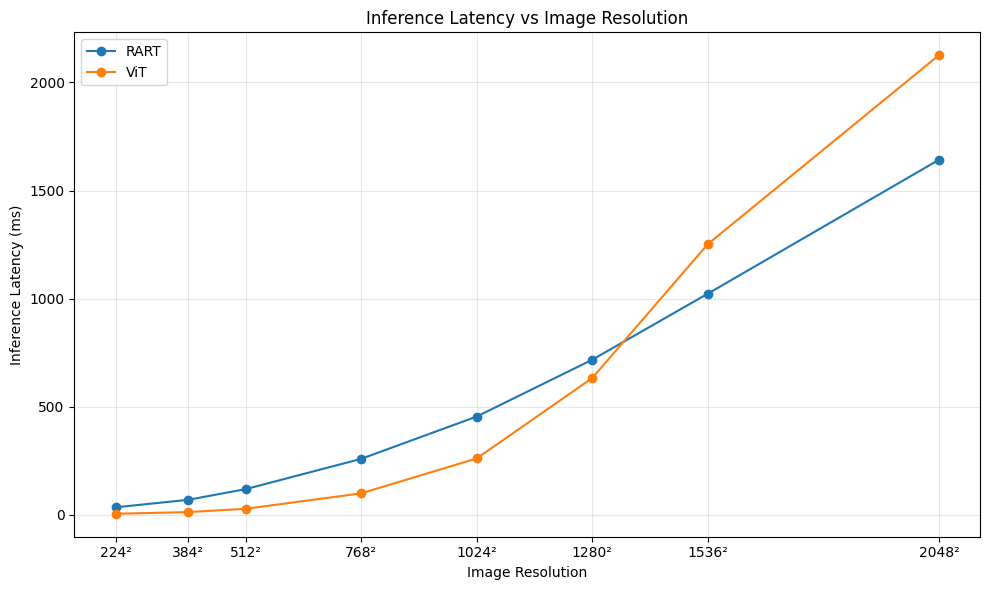

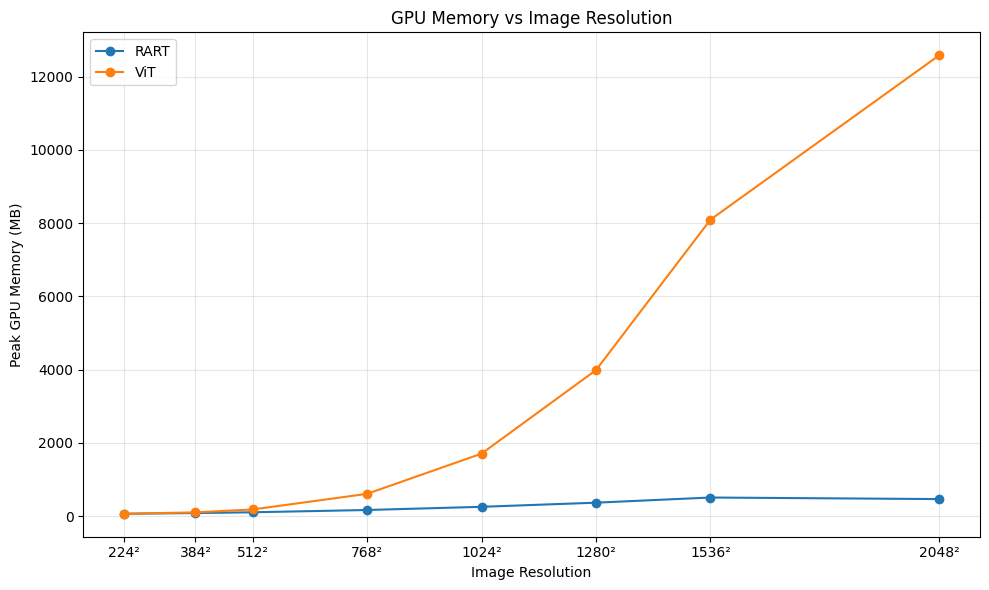

In [9]:
import matplotlib.pyplot as plt

common = sorted(set(rart_results) & set(vit_results))
if common:
    plt.figure(figsize=(10, 6))
    plt.plot(common, [rart_results[r]["latency_ms"] for r in common], marker="o", label="RART")
    plt.plot(common, [vit_results[r]["latency_ms"] for r in common], marker="o", label="ViT")
    plt.xlabel("Image Resolution")
    plt.ylabel("Inference Latency (ms)")
    plt.title("Inference Latency vs Image Resolution")
    plt.xticks(common, [f"{r}²" for r in common])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(common, [rart_results[r]["peak_memory_mb"] for r in common], marker="o", label="RART")
    plt.plot(common, [vit_results[r]["peak_memory_mb"] for r in common], marker="o", label="ViT")
    plt.xlabel("Image Resolution")
    plt.ylabel("Peak GPU Memory (MB)")
    plt.title("GPU Memory vs Image Resolution")
    plt.xticks(common, [f"{r}²" for r in common])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. 2048×2048 comparison

In [10]:
rows = []
if 2048 in rart_results:
    rows.append(("RART", rart_results[2048]))
if 2048 in vit_results:
    rows.append(("ViT", vit_results[2048]))
for name, result in baseline_results.items() if 'baseline_results' in globals() else []:
    rows.append((name, result))

for name, result in rows:
    print(f"{name:16s} | latency={result['latency_ms']:.3f} ms | memory={result['peak_memory_mb']:.2f} MB | throughput={result['throughput']:.2f}/s")

RART             | latency=1641.761 ms | memory=463.15 MB | throughput=0.61/s
ViT              | latency=2125.234 ms | memory=12582.03 MB | throughput=0.47/s
PVTv2-B1         | latency=804.778 ms | memory=1900.82 MB | throughput=1.24/s
EfficientViT-B2  | latency=207.212 ms | memory=1006.80 MB | throughput=4.83/s


## Notes

- The notebook no longer reads or executes another notebook at runtime.
- `torch.nn.functional as F` is imported explicitly.
- The resolution-agnostic local window implementation is defined before any RART model is instantiated.
- Each high-resolution benchmark is run sequentially and its model/input are deleted before the next benchmark.
- CUDA OOM during a benchmark is caught so a single oversized baseline does not abort the entire Kaggle version.
- The Swin-Tiny monkey-patching experiment was removed because it was an exploratory debugging path and was not part of the final reported comparison.